# STEP 05 — Tabular Q-Learning from Scratch

Itt történik az első tényleges reinforcement learning. A Q-Learninget saját implementációval használjuk, mert ezen keresztül a Bellman-frissítés, exploration/exploitation és state discretization **látható és ellenőrizhető**, nem egy library belsejében történik.

In [1]:
from pathlib import Path
import sys, json, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Image

ROOT = Path.cwd()
if ROOT.name == "workflow":
    ROOT = ROOT.parent
SRC = ROOT / "src"
for p in [ROOT, SRC]:
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

from workflow.shared.utils import ensure_data, load_config, build_env

cfg = load_config()
full, train, val, test = ensure_data()
FIG_DIR = ROOT / "04_results" / "figures"
METRIC_DIR = ROOT / "04_results" / "metrics"
MODEL_DIR = ROOT / "04_results" / "models"
PRED_DIR = ROOT / "04_results" / "predictions"
for p in [FIG_DIR, METRIC_DIR, MODEL_DIR, PRED_DIR]:
    p.mkdir(parents=True, exist_ok=True)

QUICK_MODE = True  # GitHub notebookhoz gyors futás. Komolyabb benchmarkhoz állítsd False-ra.
SEEDS = [42, 123, 2026]
print(f"Project root: {ROOT}")
print(f"Rows: full={len(full):,}, train={len(train):,}, validation={len(val):,}, test={len(test):,}")

Project root: /mnt/data/smart_battery_energy_management_rl
Rows: full=8,760, train=6,132, validation=1,314, test=1,314


## 1. Q-function és Bellman equation

A `Q(s,a)` azt becsüli, hogy az `s` state-ben az `a` action választása után mekkora diszkontált hosszú távú return várható.

**Update:** `Q(s,a) ← Q(s,a) + α [r + γ maxₐ Q(s',a) − Q(s,a)]`

- `α`: learning rate — mennyire írjuk felül a régi becslést;
- `γ`: discount factor — mennyire számít a jövő;
- a zárójeles rész a **TD error**.

In [2]:
from battery_rl.agents.q_learning import StateDiscretizer, TabularQLearningAgent, train_q_learning
from battery_rl.evaluation import evaluate_policy
from workflow.step05_q_learning import make_agent

env = build_env(train, cfg, random_start=True)
agent_demo = make_agent(cfg, 42)
print(agent_demo.discretizer)

StateDiscretizer(soc_bins=5, price_bins=5, demand_bins=3, renewable_bins=3, hour_bins=4, forecast_bins=5)


## 2. Miért kell discretization?

A state változói folytonosak, de a tabular Q-Learning véges kulcsokhoz tárol Q-vektort. Ezért a normalizált SOC/price/demand/renewable/hour értékeket bin-ekbe osztjuk.

In [3]:
obs, info = env.reset(seed=42)
state_key = agent_demo.discretizer.transform(obs)
pd.DataFrame({"feature": env.obs_columns, "normalized_obs": obs, "discrete_bin": state_key})

,feature,normalized_obs,discrete_bin
0,soc,0.500000,2
1,electricity_price_eur_per_kwh,0.352780,1
2,electricity_demand_kw,0.583463,1
3,renewable_generation_kw,0.193707,0
4,hour_of_day,0.739130,2


### State-space méret

A bin-számok szorzata adja a **lehetséges** diszkrét state-ek számát. Ez gyorsan felrobbanhat — ez a curse of dimensionality egyik egyszerű megjelenése.

In [4]:
qcfg = cfg["q_learning"]
possible_states = qcfg["soc_bins"] * qcfg["price_bins"] * qcfg["demand_bins"] * qcfg["renewable_bins"] * qcfg["hour_bins"]
print("Possible discrete states:", possible_states)
print("Q values if every state were visited:", possible_states * 3)

Possible discrete states: 900
Q values if every state were visited: 2700


## 3. Epsilon-greedy exploration

Training elején magas epsilon mellett az agent sokat próbálkozik. Később epsilon csökken, és egyre gyakrabban használja a jelenleg legjobb Q-értékű actiont.

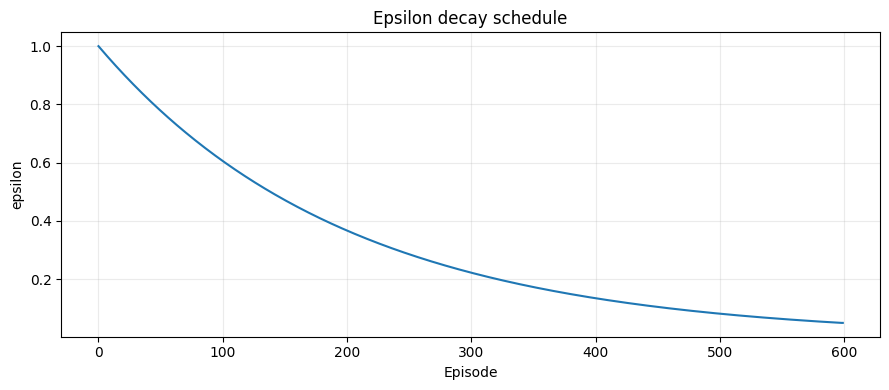

In [5]:
episodes_preview = np.arange(0, int(cfg["q_learning"]["episodes"]))
eps = np.maximum(cfg["q_learning"]["epsilon_end"], cfg["q_learning"]["epsilon_start"] * (cfg["q_learning"]["epsilon_decay"] ** episodes_preview))
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(episodes_preview, eps)
ax.set_title("Epsilon decay schedule")
ax.set_xlabel("Episode"); ax.set_ylabel("epsilon"); ax.grid(alpha=0.25)
fig.tight_layout(); fig.savefig(FIG_DIR / "nb05_01_epsilon_decay.png", dpi=170, bbox_inches="tight")
plt.show()

## 4. Több seed-es Q-Learning training

Egyetlen random seed alapján nem szabad azt állítani, hogy egy RL algoritmus stabil. Három külön seedet futtatunk ugyanazzal a hyperparameter konfigurációval.

In [6]:
episodes = 140 if QUICK_MODE else int(cfg["q_learning"]["episodes"])
curves = {}
agents = {}
visited = {}
for seed in SEEDS:
    env_seed = build_env(train, cfg, random_start=True)
    agent = make_agent(cfg, seed)
    returns, eps_history = train_q_learning(env_seed, agent, episodes=episodes, seed=seed)
    curves[seed] = returns
    agents[seed] = agent
    visited[seed] = len(agent.q)
print("Visited Q-table states:", visited)

Visited Q-table states: {42: 120, 123: 117, 2026: 114}


## 5. Training curves — nyers return és rolling mean

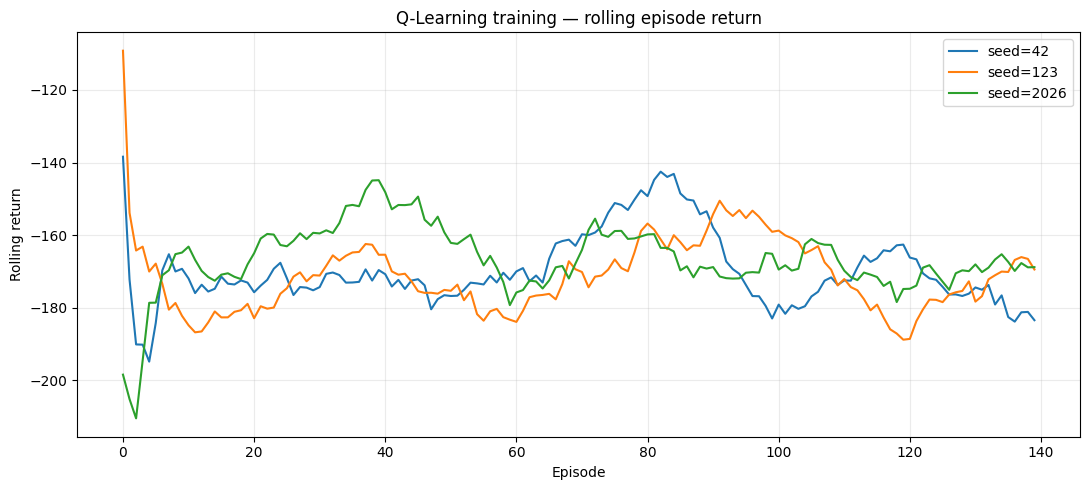

In [7]:
fig, ax = plt.subplots(figsize=(11, 5))
for seed, values in curves.items():
    s = pd.Series(values)
    ax.plot(s.rolling(20, min_periods=1).mean(), label=f"seed={seed}")
ax.set_title("Q-Learning training — rolling episode return")
ax.set_xlabel("Episode"); ax.set_ylabel("Rolling return"); ax.legend(); ax.grid(alpha=0.25)
fig.tight_layout(); fig.savefig(FIG_DIR / "nb05_02_multiseed_training.png", dpi=170, bbox_inches="tight")
plt.show()

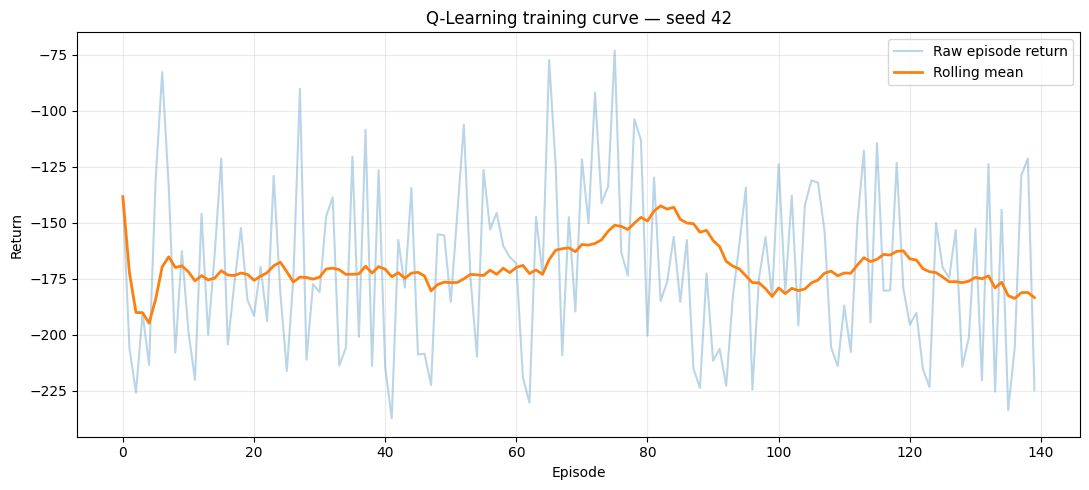

In [8]:
seed = 42
s = pd.Series(curves[seed])
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(s, alpha=0.30, label="Raw episode return")
ax.plot(s.rolling(20, min_periods=1).mean(), linewidth=2, label="Rolling mean")
ax.set_title("Q-Learning training curve — seed 42")
ax.set_xlabel("Episode"); ax.set_ylabel("Return"); ax.legend(); ax.grid(alpha=0.25)
fig.tight_layout(); fig.savefig(FIG_DIR / "nb05_03_training_raw_rolling.png", dpi=170, bbox_inches="tight")
plt.show()

## 6. Mennyi state-et látott ténylegesen az agent?

,seed,visited_states,possible_states,coverage_pct
0,42,120,900,13.333333
1,123,117,900,13.000000
2,2026,114,900,12.666667


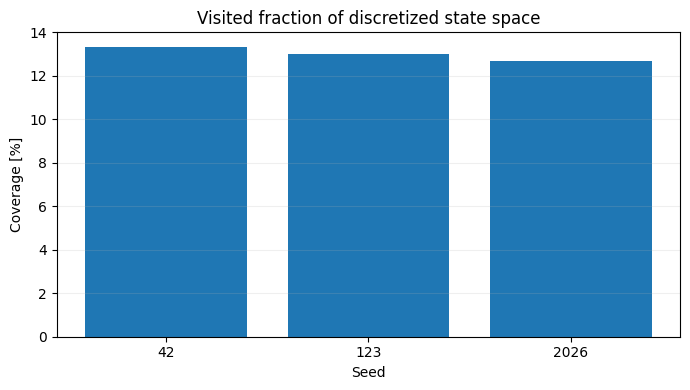

In [9]:
state_coverage = pd.DataFrame({
    "seed": SEEDS,
    "visited_states": [visited[s] for s in SEEDS],
    "possible_states": possible_states,
})
state_coverage["coverage_pct"] = 100 * state_coverage.visited_states / state_coverage.possible_states
display(state_coverage)
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(state_coverage.seed.astype(str), state_coverage.coverage_pct)
ax.set_title("Visited fraction of discretized state space")
ax.set_xlabel("Seed"); ax.set_ylabel("Coverage [%]"); ax.grid(axis="y", alpha=0.2)
fig.tight_layout(); fig.savefig(FIG_DIR / "nb05_04_state_coverage.png", dpi=170, bbox_inches="tight")
plt.show()

Ez a grafikon megmutatja a tabular módszer alapvető korlátját: ha túl finom a discretization, rengeteg state ritkán vagy soha nem kap megbízható Q-becslést.

## 7. Validation és test értékelés

In [10]:
primary = agents[42]
primary.save(MODEL_DIR / "q_learning_agent.pkl")
val_metrics, _ = evaluate_policy(lambda: build_env(val, cfg, random_start=True), primary, seeds=SEEDS, episodes=8 if QUICK_MODE else 30)
test_metrics, q_logs = evaluate_policy(lambda: build_env(test, cfg, random_start=True), primary, seeds=SEEDS, episodes=8 if QUICK_MODE else 30)
summary = pd.DataFrame({
    "validation_mean": val_metrics.mean(numeric_only=True),
    "test_mean": test_metrics.mean(numeric_only=True),
    "test_std": test_metrics.std(numeric_only=True),
})
display(summary)

,validation_mean,test_mean,test_std
total_electricity_cost,132.022781,102.105969,12.547963
peak_grid_demand_kw,81.835210,76.336370,7.697629
renewable_self_consumption_pct,93.344326,78.905706,5.832519
battery_throughput_kwh,214.006579,215.259868,82.566622
battery_cycles,0.891694,0.896916,0.344028
constraint_violations,2.125000,2.375000,0.517549
average_soc,0.377118,0.325641,0.172717
cumulative_reward,-136.034301,-105.596146,12.994400
episode_return,-136.034301,-105.596146,12.994400


## 8. Q-értékek egy konkrét state-ben

A Q-vektor sorrendje `[charge, idle, discharge]`. Nem probability: mindhárom szám becsült hosszú távú return.

In [11]:
env_eval = build_env(test, cfg, random_start=False)
obs, _ = env_eval.reset(seed=42, options={"start_index": 0})
state = primary.discretizer.transform(obs)
q_values = primary._values(state)
pd.DataFrame({"action":["charge","idle","discharge"], "Q(s,a)":q_values})

,action,"Q(s,a)"
0,charge,-12.421423
1,idle,-11.384140
2,discharge,-12.466235


## 9. Learned policy heatmap — price × SOC → action

Ez az egyik legjobb interpretációs ábra. Fix tipikus demand/renewable/hour mellett végigpásztázzuk a price és SOC kombinációkat, majd lekérdezzük, hogy a Q-table melyik actiont választaná.

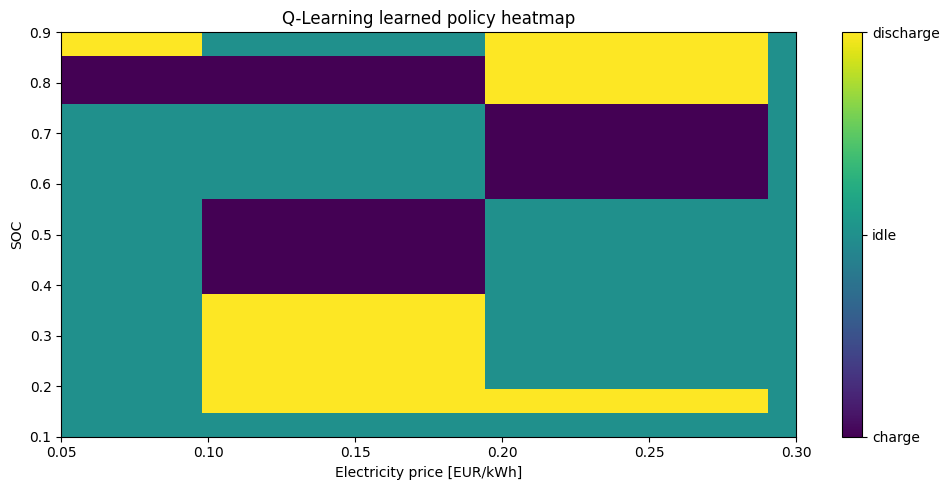

In [12]:
socs = np.linspace(0.1, 0.9, 17)
prices = np.linspace(0.05, 0.30, 26)
mat = np.zeros((len(socs), len(prices)), dtype=int)
for i, soc in enumerate(socs):
    for j, price in enumerate(prices):
        raw = np.array([soc, price, 0.55*env_eval._demand_max, 0.15*env_eval._renewable_max, 18], dtype=np.float32)
        scale = np.array([1.0, env_eval._price_max, env_eval._demand_max, env_eval._renewable_max, 23.0], dtype=np.float32)
        obs = raw / scale
        state = primary.discretizer.transform(obs)
        q = primary._values(state)
        valid = [1] + ([0] if soc < env_eval.spec.max_soc-1e-8 else []) + ([2] if soc > env_eval.spec.min_soc+1e-8 else [])
        mat[i,j] = max(valid, key=lambda a: q[a])
fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(mat, aspect="auto", origin="lower", extent=[prices.min(), prices.max(), socs.min(), socs.max()], vmin=0, vmax=2)
ax.set_title("Q-Learning learned policy heatmap")
ax.set_xlabel("Electricity price [EUR/kWh]"); ax.set_ylabel("SOC")
cbar = fig.colorbar(im, ax=ax, ticks=[0,1,2]); cbar.ax.set_yticklabels(["charge","idle","discharge"])
fig.tight_layout(); fig.savefig(FIG_DIR / "nb05_05_q_policy_heatmap.png", dpi=170, bbox_inches="tight")
plt.show()

## 10. Mire figyeljünk az eredmény értelmezésénél?

A Q-Learning célja itt elsősorban **tanulási eszköz**. Ha a rule-based controller jobb, annak több oka lehet: kevés episode, durva state discretization, reward trade-off, ritkán látott state-ek vagy egyszerűen az, hogy a baseline jól illeszkedik az árstruktúrához.

Ez pontosan az a mérnöki gondolkodás, amit egy portfólióban érdemes megmutatni: nem azt állítjuk, hogy „RL mindig jobb”, hanem mérjük és elemezzük, mikor ad értéket.